# A3 — Bilayer hBN: bands & 2D phonons

Companion notebook to Advanced chapter A3. Two stacked panels over the same
Γ–M–K–Γ path: the electronic bands (`bn.bands.gnu`, a wide-gap insulator)
and the DFPT phonon dispersion (`bn.freq.gp`) with the **2D LO–TO** feature
from `loto_2d`. Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

d = Path('../code/advanced/03-bilayer-hbn')
VBM = -5.838   # eV, from scf.out (highest occupied)

def blocks(fname):
    bl, cur = [], []
    for line in (d/fname).read_text().splitlines():
        if line.strip(): cur.append([float(x) for x in line.split()[:2]])
        elif cur: bl.append(np.array(cur)); cur = []
    if cur: bl.append(np.array(cur))
    return bl

bb = blocks('bn.bands.gnu')
kb = bb[0][:, 0]; E = np.array([b[:, 1] for b in bb]) - VBM
# phonon: freq.gp is one row per q with all 12 modes
ph = np.loadtxt(d/'bn.freq.gp'); kp = ph[:, 0]; F = ph[:, 1:]

ticks, labels = [], []
for line in (d/'highsym.dat').read_text().splitlines():
    if line.strip() and not line.startswith('#'):
        x, lab = line.split(); ticks.append(float(x)); labels.append(lab)

vbm = E[7].max(); cbm = E[8].min()
print(f'PBE gap = {cbm - vbm:.2f} eV  (VBM at k={kb[E[7].argmax()]:.3f}, CBM at k={kb[E[8].argmin()]:.3f})')
iG = 0
print(f'Γ optical (cm^-1): {np.round(np.sort(F[iG])[-4:],1)};  just off Γ top mode: {np.sort(F[1])[-1]:.1f}')

PBE gap = 4.53 eV  (VBM at k=0.937, CBM at k=0.577)
Γ optical (cm^-1): [1352.  1352.  1352.1 1352.1];  just off Γ top mode: 1409.5


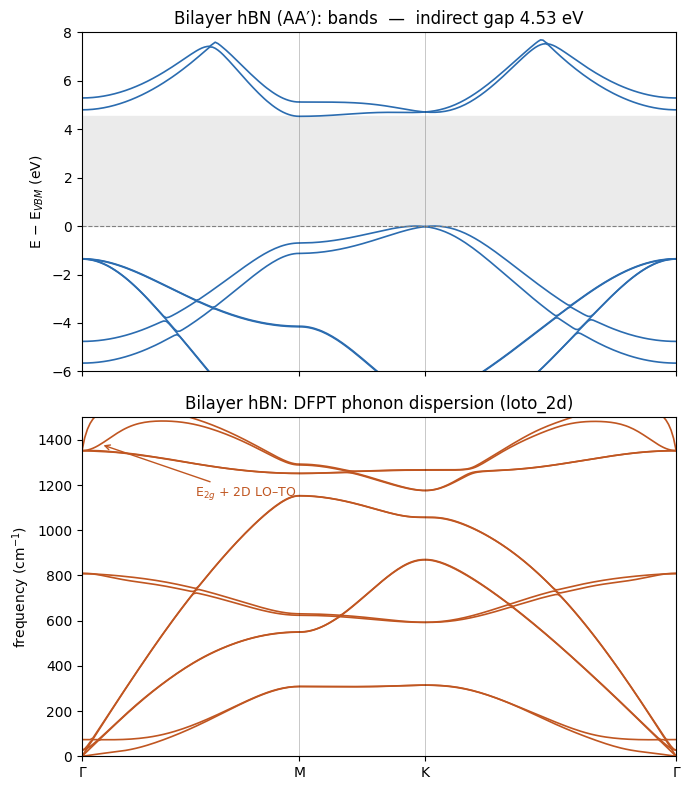

In [2]:
import matplotlib.pyplot as plt

fig, (axe, axp) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
# electronic bands
for b in E: axe.plot(kb, b, color='#2b6cb0', lw=1.2)
axe.axhline(0, color='gray', ls='--', lw=0.8)
axe.axhspan(0, (E[8].min()), color='0.92')
axe.set_ylim(-6, 8); axe.set_ylabel('E − E$_{VBM}$ (eV)')
axe.set_title('Bilayer hBN (AA′): bands  —  indirect gap 4.53 eV')
# phonons
for ib in range(F.shape[1]): axp.plot(kp, F[:, ib], color='#c05621', lw=1.2)
axp.axhline(0, color='gray', lw=0.6)
axp.annotate('E$_{2g}$ + 2D LO–TO', xy=(0.05, 1380), xytext=(0.3, 1150),
             color='#c05621', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='#c05621'))
axp.set_ylim(0, 1500); axp.set_ylabel('frequency (cm$^{-1}$)')
axp.set_title('Bilayer hBN: DFPT phonon dispersion (loto_2d)')
for ax in (axe, axp):
    for x in ticks: ax.axvline(x, color='k', lw=0.5, alpha=0.3)
    ax.set_xlim(kb.min(), kb.max())
axp.set_xticks(ticks); axp.set_xticklabels(labels)
fig.tight_layout()
fig.savefig(d.parent.parent.parent/'static/img/A3-bilayer-hbn.png', dpi=120)
plt.show()

**What you see.** *Top:* bilayer hBN is a **wide-gap insulator** — PBE
gives an **indirect** gap of ~4.5 eV (VBM near K, CBM near M), the opposite
extreme from graphene's zero-gap Dirac cone. *Bottom:* the phonon
dispersion has the famous high-frequency **E$_{2g}$** optical modes near
1350–1400 cm⁻¹. Because hBN is **polar** and we set `loto_2d=.true.`, the
longitudinal-optical branch shows the **2D LO–TO** behaviour: the splitting
vanishes exactly at Γ but rises **linearly** in q away from it (a 2D
fingerprint — in 3D the LO–TO split is a finite jump at Γ instead). The
lowest acoustic branch is the out-of-plane **ZA flexural** mode. None of
this exists for graphene (non-polar) — it needs a polar 2D crystal.